In [1]:
import pandas as pd
import os
import numpy as np

DATA_DIR = "../data"

# 1. Load Data
df_routes = pd.read_csv(os.path.join(DATA_DIR, "routes.csv"))
df_stops = pd.read_csv(os.path.join(DATA_DIR, "route_stops.csv"))

# 2. Master Merge (Now bringing in temperature_c)
df_master = pd.merge(
    df_stops, 
    df_routes[['route_id', 'vehicle_type', 'weather_condition', 'traffic_level', 'road_incident', 'temperature_c']], 
    on='route_id', 
    how='left'
)

# 3. Target Variable
df_clean = df_master[df_master['delay_at_stop_min'] <= 360].copy()

print(f"✅ Data Ready for ML! Training on {len(df_clean)} segments.")

✅ Data Ready for ML! Training on 1451 segments.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

# 1. Group our features
categorical_features = ['road_type', 'vehicle_type', 'weather_condition', 'traffic_level']
numeric_features = ['temperature_c', 'distance_from_prev_km', 'planned_travel_min', 'stop_sequence', 'package_weight_kg']
binary_features = ['road_incident'] 

# Combine numeric and binary since both just pass directly through to the math engine
passthrough_features = numeric_features + binary_features
features = categorical_features + passthrough_features

X = df_clean[features]
y = df_clean['delay_at_stop_min']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Lean Preprocessor (Translates text, leaves numbers completely alone)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ]
)

# 4. Master Pipeline
ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=150,      
        learning_rate=0.1,     
        max_depth=5,           
        random_state=42
    ))
])

print("✅ Lean Machine Learning Pipeline Constructed!")

✅ Lean Machine Learning Pipeline Constructed!


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("🧠 Training XGBoost AI... (This will be fast)")

ml_pipeline.fit(X_train, y_train)
predictions = ml_pipeline.predict(X_test)

# Calculate the metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"✅ Training Complete!")
print(f"📊 Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"📊 Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"📊 R² Score: {r2:.3f}")

# Quick side-by-side comparison
comparison = pd.DataFrame({
    'Actual Delay': y_test.values[:10], 
    'AI Predicted': predictions[:10],
    'Difference': (y_test.values[:10] - predictions[:10])
})
display(comparison.round(1))

🧠 Training XGBoost AI... (This will be fast)
✅ Training Complete!
📊 Mean Absolute Error (MAE): 3.32 minutes
📊 Root Mean Squared Error (RMSE): 6.67 minutes
📊 R² Score: 0.964


,Actual Delay,AI Predicted,Difference
0,51.8,54.700001,-2.9
1,10.2,10.800000,-0.6
2,7.1,9.100000,-2.0
3,8.8,9.500000,-0.7
4,3.0,4.000000,-1.0
5,21.3,19.799999,1.5
6,7.8,12.100000,-4.3
7,44.9,49.200001,-4.3
8,35.5,38.599998,-3.1
9,3.9,4.800000,-0.9


In [12]:
import joblib
import os
import json

MODEL_DIR = "../trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Save the Model
MODEL_PATH = os.path.join(MODEL_DIR, "xgboost_delay_model.pkl")
joblib.dump(ml_pipeline, MODEL_PATH)
print(f"🚀 SUCCESS! Model saved directly to API folder: {MODEL_PATH}")

# 2. Save the API Metadata for the Node.js team
metadata = {
    "target": "delay_at_stop_min",
    "expected_features": features,
    "feature_types": {
        "categorical": categorical_features,
        "numeric": numeric_features,
        "binary": passthrough_features
    }
}

META_PATH = os.path.join(MODEL_DIR, "model_metadata.json")
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=4)
    
print(f"✅ API Metadata saved to: {META_PATH}")

🚀 SUCCESS! Model saved directly to API folder: ../trained_models\xgboost_delay_model.pkl
✅ API Metadata saved to: ../trained_models\model_metadata.json


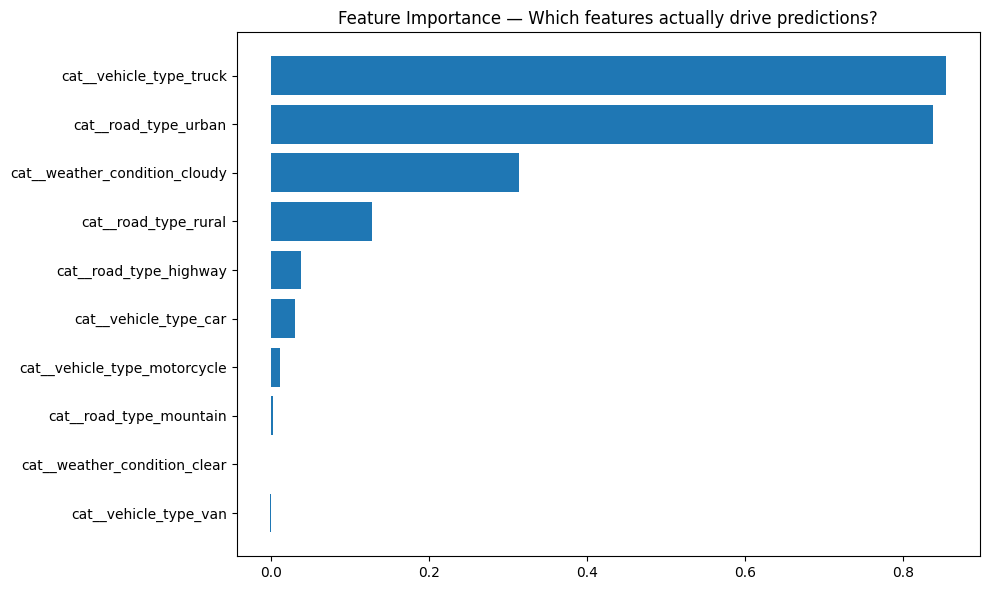

In [13]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Get feature names after encoding
feature_names = (
    ml_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

result = permutation_importance(ml_pipeline, X_test, y_test, n_repeats=10, random_state=42)

# Plot top 15 features
sorted_idx = result.importances_mean.argsort()[-15:]
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Feature Importance — Which features actually drive predictions?")
plt.tight_layout()
plt.show()